In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [134]:
df = pd.read_csv('data/train.csv')

In [135]:
df.shape

(593994, 13)

In [136]:
df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [137]:
# Nie ma nulli 
df.isnull().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [138]:
# nie ma zduplikowanych wierszy
df.duplicated().sum()

np.int64(0)

In [139]:
# podstawowe statystyki
cols = ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']

desc = df[cols].describe()

desc.loc['median'] = df[cols].median()
desc.loc['mode'] = df[cols].mode().iloc[0]

desc = desc.drop('count')

desc

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate
mean,48212.202976,0.120696,680.916009,15020.297629,12.356345
std,26711.942078,0.068573,55.424956,6926.530568,2.008959
min,6002.430000,0.011000,395.000000,500.090000,3.200000
25%,27934.400000,0.072000,646.000000,10279.620000,10.990000
50%,46557.680000,0.096000,682.000000,15000.220000,12.370000
75%,60981.320000,0.156000,719.000000,18858.580000,13.680000
max,393381.740000,0.627000,849.000000,48959.950000,20.990000
median,46557.680000,0.096000,682.000000,15000.220000,12.370000
mode,51351.710000,0.090000,678.000000,12892.250000,12.310000


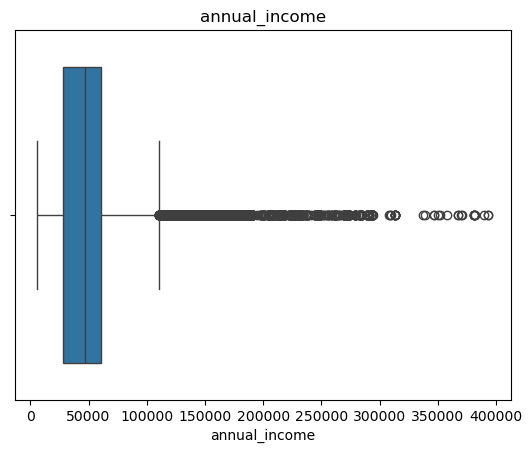

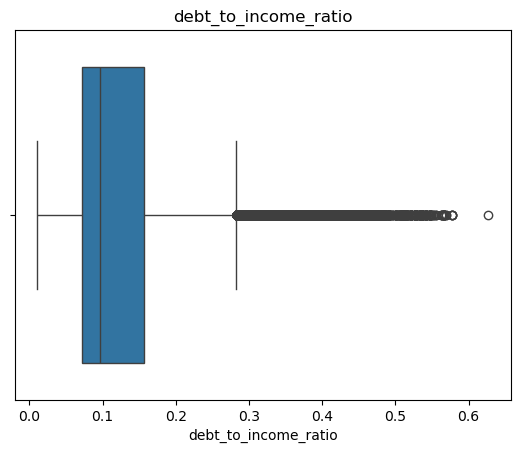

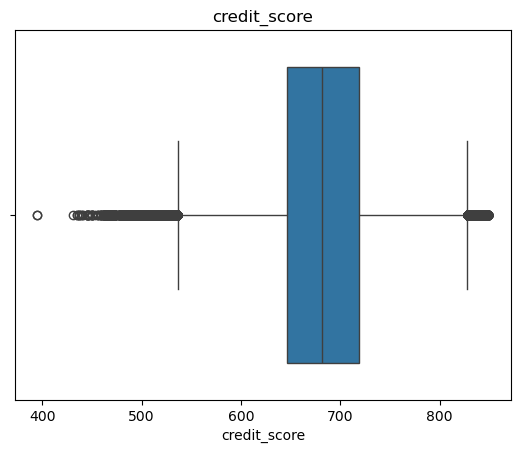

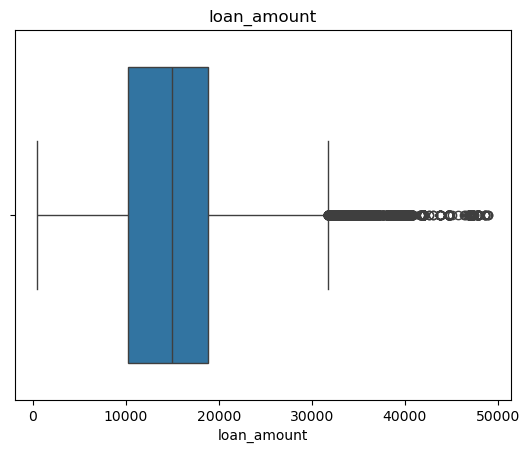

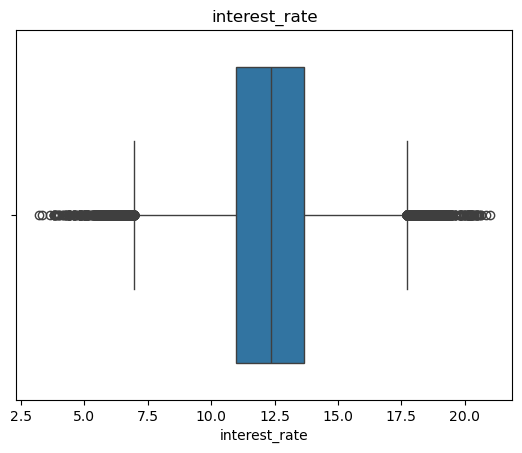

In [140]:
for c in cols:
    sns.boxplot(x=df[c])
    plt.title(c)
    plt.show()

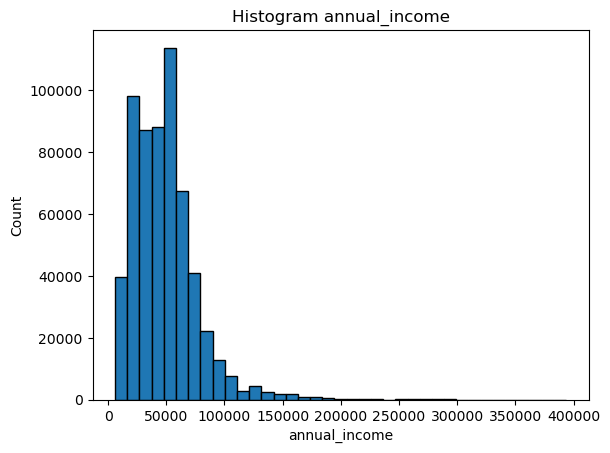

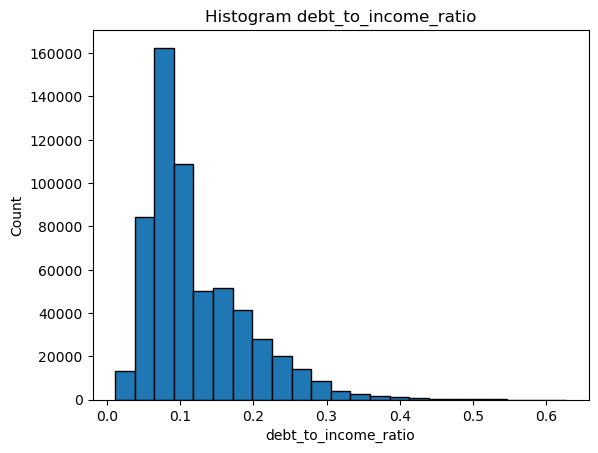

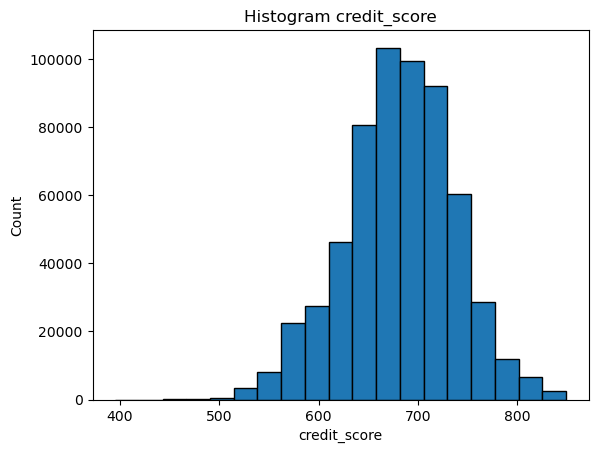

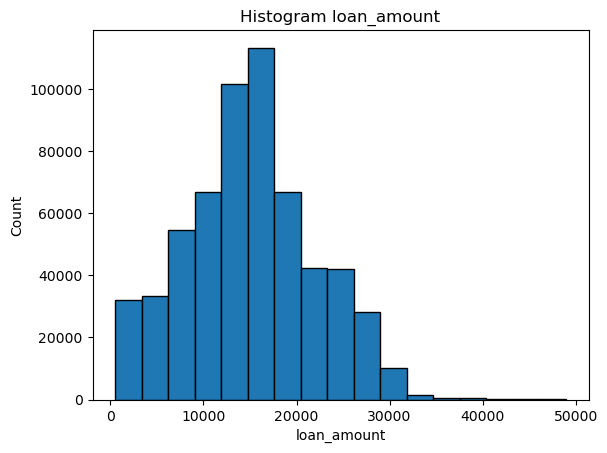

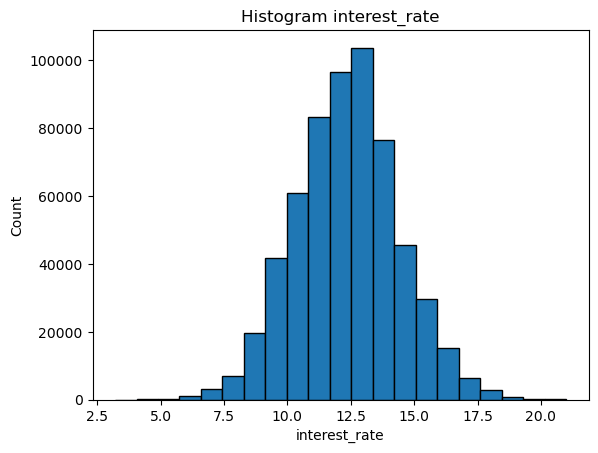

In [141]:
for c in cols:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    h = 2.64 * IQR * pow(len(df[c]),(-1/3))  
    num_bins = int(((df[c].max()-df[c].min())/h)/10)

    plt.hist(df[c], bins=num_bins, edgecolor='black')
    plt.title('Histogram ' + c)
    plt.xlabel(c)
    plt.ylabel('Count')
    plt.show()

In [142]:
# macierz korelacji
df[cols].corr()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate
annual_income,1.000000,0.000553,0.001509,-0.003407,-0.002507
debt_to_income_ratio,0.000553,1.000000,-0.061617,-0.008236,0.030316
credit_score,0.001509,-0.061617,1.000000,-0.005761,-0.538335
loan_amount,-0.003407,-0.008236,-0.005761,1.000000,-0.001174
interest_rate,-0.002507,0.030316,-0.538335,-0.001174,1.000000


In [143]:
cols2 =[]

for c in cols:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    
    h = 2.64 * IQR * pow(len(df[c]),(-1/3)) * 20
    
    df[c+'_label'] = ((df[c] - df[c].min()) / h).astype(int)    
    cols2.append(c+'_label')
    print(c, 'buckets number', set(df[c+'_label']))
    
cols2.extend(['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade'])

annual_income buckets number {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18}
debt_to_income_ratio buckets number {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}
credit_score buckets number {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
loan_amount buckets number {0, 1, 2, 3, 4, 5, 6, 7, 8}
interest_rate buckets number {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10}


In [144]:
cols2

['annual_income_label',
 'debt_to_income_ratio_label',
 'credit_score_label',
 'loan_amount_label',
 'interest_rate_label',
 'gender',
 'marital_status',
 'education_level',
 'employment_status',
 'loan_purpose',
 'grade_subgrade']

In [145]:
df

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,annual_income_label,debt_to_income_ratio_label,credit_score_label,loan_amount_label,interest_rate_label
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0,1,1,7,0,6
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0,0,2,5,0,5
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0,2,1,6,3,3
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0,1,1,3,0,7
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0,0,0,5,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1.0,0,2,6,3,4
593990,593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1.0,1,1,3,0,6
593991,593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1.0,1,1,6,0,6
593992,593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1.0,3,1,7,2,3


In [146]:
df_paid = df.query('loan_paid_back==1')

In [147]:
df_paid

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,annual_income_label,debt_to_income_ratio_label,credit_score_label,loan_amount_label,interest_rate_label
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0,1,1,7,0,6
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0,2,1,6,3,3
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0,1,1,3,0,7
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0,0,0,5,2,4
5,5,44940.30,0.058,653,12159.92,12.24,Male,Single,Bachelor's,Employed,Other,D1,1.0,1,0,5,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1.0,0,2,6,3,4
593990,593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1.0,1,1,3,0,6
593991,593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1.0,1,1,6,0,6
593992,593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1.0,3,1,7,2,3


In [148]:
# stosunek osób, które spłaciły w danej kategorii do ogółu osób w tej kategorii; im większa wartość tym "bezpieczniejsza" grupa 
# jeśli >1 -> grupa spłaca kredyt częściej niż średnio w populacji
# jeśli =1 -> grupa spłaca kredyt w proporcji w jakiej należy do populacji
# jeśli <1 -> grupa spłaca kredyt rzadziej niż średnio w populacji

# 11  NaN w debt_to_income_ratio_label, bo z osób, które spłaciły kredyt, nikt nie należy do tej grupy

for c in cols2:
    ratio =  df_paid[c].value_counts(normalize=True) / df[c].value_counts(normalize=True)
    print(ratio, '\n')

annual_income_label
0     0.996750
1     0.994280
2     1.002232
3     1.014834
4     1.025324
5     0.997880
6     0.952151
7     0.946803
8     0.975451
9     0.834565
10    0.938885
11    0.919724
12    0.938885
13    0.972719
14    0.910434
15    1.251847
16    0.834565
17    0.938885
18    0.973659
Name: proportion, dtype: float64 

debt_to_income_ratio_label
0     1.153647
1     1.088395
2     1.006571
3     0.769164
4     0.603967
5     0.615597
6     0.554262
7     0.442031
8     0.364787
9     0.338510
10    0.171822
11         NaN
Name: proportion, dtype: float64 

credit_score_label
0    0.751108
1    0.839474
2    0.696821
3    0.786593
4    0.819943
5    0.908923
6    1.037365
7    1.128160
8    1.193219
9    1.201817
Name: proportion, dtype: float64 

loan_amount_label
2    0.996346
3    0.992509
1    1.015104
4    1.001616
0    0.991899
5    1.020611
6    0.950792
7    0.906022
8    0.876293
Name: proportion, dtype: float64 

interest_rate_label
5     1.004701
4     1.05

In [5]:
# ~80% jest spłaconych kredytów, jest niezrównowazenie między spłaconymi i nie
df['loan_paid_back'].value_counts(normalize=True)

loan_paid_back
1.0    0.79882
0.0    0.20118
Name: proportion, dtype: float64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


In [7]:
df.nunique()

id                      593994
annual_income           119728
debt_to_income_ratio       526
credit_score               399
loan_amount             111570
interest_rate             1454
gender                       3
marital_status               4
education_level              5
employment_status            5
loan_purpose                 8
grade_subgrade              30
loan_paid_back               2
dtype: int64

In [8]:
cat_col = df.select_dtypes(include='object').columns.tolist()
num_col = df.select_dtypes(include='number').columns.tolist()

In [9]:
num_col

['id',
 'annual_income',
 'debt_to_income_ratio',
 'credit_score',
 'loan_amount',
 'interest_rate',
 'loan_paid_back']

In [10]:
df[cat_col].nunique()

gender                3
marital_status        4
education_level       5
employment_status     5
loan_purpose          8
grade_subgrade       30
dtype: int64

In [11]:
df['gender'].value_counts(normalize=True)

gender
Female    0.515451
Male      0.478273
Other     0.006276
Name: proportion, dtype: float64

In [12]:
df['marital_status'].value_counts()

marital_status
Single      288843
Married     277239
Divorced     21312
Widowed       6600
Name: count, dtype: int64

In [13]:
df['education_level'].value_counts()

education_level
Bachelor's     279606
High School    183592
Master's        93097
Other           26677
PhD             11022
Name: count, dtype: int64

In [14]:
df['employment_status'].value_counts()

employment_status
Employed         450645
Unemployed        62485
Self-employed     52480
Retired           16453
Student           11931
Name: count, dtype: int64

In [15]:
df['loan_purpose'].value_counts()

loan_purpose
Debt consolidation    324695
Other                  63874
Car                    58108
Home                   44118
Education              36641
Business               35303
Medical                22806
Vacation                8449
Name: count, dtype: int64

In [16]:
df['grade_subgrade'].value_counts()

grade_subgrade
C3    58695
C4    55957
C2    54443
C1    53363
C5    53317
D1    37029
D3    36694
D4    35097
D2    34432
D5    32101
B2    15167
B1    14344
B5    13937
B3    13926
B4    13877
E4     8036
E3     7075
E1     6891
E2     6372
E5     6084
F5     5947
F4     5535
F1     5534
F2     5203
F3     5082
A5     2471
A3     2066
A2     2018
A4     1701
A1     1600
Name: count, dtype: int64

In [17]:
df_ex = df.copy()
df_ex['grade_letter'] = df['grade_subgrade'].str[0]
df_ex['subgrade_num'] = df['grade_subgrade'].str[1:].astype(int)

In [18]:
del df_ex['id']

In [19]:
del df_ex['grade_subgrade']

In [20]:
df_ex

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,loan_paid_back,grade_letter,subgrade_num
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,1.0,C,3
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,0.0,D,3
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,1.0,C,5
3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,1.0,F,1
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,1.0,D,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,1.0,C,3
593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,1.0,F,5
593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,1.0,C,1
593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,1.0,B,2


In [21]:
grade_map = {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6}
df_ex['grade_letter_rank'] = df_ex['grade_letter'].map(grade_map)

In [22]:
del df_ex['grade_letter']

In [23]:
df_ex

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,loan_paid_back,subgrade_num,grade_letter_rank
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,1.0,3,3
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,0.0,3,4
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,1.0,5,3
3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,1.0,1,6
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,1.0,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,1.0,3,3
593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,1.0,5,6
593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,1.0,1,3
593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,1.0,2,2


In [24]:
df_ex['education_level'].value_counts()

education_level
Bachelor's     279606
High School    183592
Master's        93097
Other           26677
PhD             11022
Name: count, dtype: int64

In [25]:
education_ranking = {"PhD": 5, "Master's": 4, "Bachelor's": 3, "High School": 2, "Other": 1}
df_ex['education_rank'] = df_ex['education_level'].map(education_ranking)

In [26]:
del df_ex['education_level']

In [27]:
df_ex

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,employment_status,loan_purpose,loan_paid_back,subgrade_num,grade_letter_rank,education_rank
0,29367.99,0.084,736,2528.42,13.67,Female,Single,Self-employed,Other,1.0,3,3,2
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Employed,Debt consolidation,0.0,3,4,4
2,49566.20,0.097,694,17005.15,9.76,Male,Single,Employed,Debt consolidation,1.0,5,3,2
3,46858.25,0.065,533,4682.48,16.10,Female,Single,Employed,Debt consolidation,1.0,1,6,2
4,25496.70,0.053,665,12184.43,10.21,Male,Married,Employed,Other,1.0,1,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,23004.26,0.152,703,20958.37,10.92,Female,Single,Employed,Business,1.0,3,3,2
593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Employed,Debt consolidation,1.0,5,6,3
593991,47112.64,0.072,675,929.27,14.13,Female,Married,Employed,Debt consolidation,1.0,1,3,3
593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Employed,Debt consolidation,1.0,2,2,3


In [28]:
df_ex = pd.get_dummies(df_ex, columns=['gender', 'marital_status', 'employment_status', 'loan_purpose'], drop_first=True)

In [29]:
df_ex

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back,subgrade_num,grade_letter_rank,education_rank,gender_Male,...,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Other,loan_purpose_Vacation
0,29367.99,0.084,736,2528.42,13.67,1.0,3,3,2,False,...,True,False,False,False,False,False,False,False,True,False
1,22108.02,0.166,636,4593.10,12.92,0.0,3,4,4,True,...,False,False,False,False,True,False,False,False,False,False
2,49566.20,0.097,694,17005.15,9.76,1.0,5,3,2,True,...,False,False,False,False,True,False,False,False,False,False
3,46858.25,0.065,533,4682.48,16.10,1.0,1,6,2,False,...,False,False,False,False,True,False,False,False,False,False
4,25496.70,0.053,665,12184.43,10.21,1.0,1,4,2,True,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,23004.26,0.152,703,20958.37,10.92,1.0,3,3,2,False,...,False,False,False,False,False,False,False,False,False,False
593990,35289.43,0.105,559,3257.24,14.62,1.0,5,6,3,True,...,False,False,False,False,True,False,False,False,False,False
593991,47112.64,0.072,675,929.27,14.13,1.0,1,3,3,False,...,False,False,False,False,True,False,False,False,False,False
593992,76748.44,0.067,740,16290.40,9.87,1.0,2,2,3,True,...,False,False,False,False,True,False,False,False,False,False


In [ ]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score

X = df_ex.drop(['loan_paid_back'], axis=1)
y = df_ex['loan_paid_back']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
    dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)
    
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'tree_method': 'hist', 
        'learning_rate': 0.05,
        'max_depth': 6,  
        'subsample': 0.8, 
        'colsample_bytree': 0.8,    
        'random_state': 42
    }
    
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=[(dtrain, 'train'), (dval, 'valid')],
        early_stopping_rounds=50,
        verbose_eval=100
    )

    oof_preds[val_idx] = model.predict(dval)
    models.append(model)
       

[0]	train-auc:0.86427	valid-auc:0.86500
[100]	train-auc:0.91713	valid-auc:0.91761
[200]	train-auc:0.92081	valid-auc:0.91950
[300]	train-auc:0.92374	valid-auc:0.92061
[400]	train-auc:0.92632	valid-auc:0.92139
[500]	train-auc:0.92860	valid-auc:0.92195
[600]	train-auc:0.93056	valid-auc:0.92230
[700]	train-auc:0.93228	valid-auc:0.92250
[800]	train-auc:0.93394	valid-auc:0.92261
[844]	train-auc:0.93466	valid-auc:0.92259
Fold 1 AUC: 0.9226
[0]	train-auc:0.86446	valid-auc:0.86431
[100]	train-auc:0.91743	valid-auc:0.91684
[200]	train-auc:0.92090	valid-auc:0.91873
[300]	train-auc:0.92395	valid-auc:0.92014
[400]	train-auc:0.92641	valid-auc:0.92092
[500]	train-auc:0.92861	valid-auc:0.92150
[600]	train-auc:0.93049	valid-auc:0.92190
[700]	train-auc:0.93228	valid-auc:0.92217
[800]	train-auc:0.93382	valid-auc:0.92228
[900]	train-auc:0.93526	valid-auc:0.92231
Fold 2 AUC: 0.9223
[0]	train-auc:0.86444	valid-auc:0.86444
[100]	train-auc:0.91764	valid-auc:0.91548
[200]	train-auc:0.92117	valid-auc:0.91723
[3

In [34]:
model.save_model('loan_repayment_model_day1.json')